In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

df = pd.read_csv('bank-full.csv', sep=';', quotechar='"')
print(df.head())


   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


## Cleaning Data

In [17]:
df.isna().sum().sort_values(ascending=False)

age                0
job                0
marital            0
education          0
default            0
balance            0
housing            0
loan               0
contact            0
day                0
month              0
campaign           0
pdays              0
previous           0
poutcome           0
y                  0
never_contacted    0
dtype: int64

We have no missing values found in this dataset.

In [12]:
#Create new binary variable for never contacted and replace -1 in pdays with 0
df['never_contacted'] = (df['pdays'] == -1).astype(int)
df['pdays'] = df['pdays'].replace(-1, 0)
df['poutcome'] = df['poutcome'].fillna("nonexistent")
#Creating unknown category for missing values in categorical variables
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('unknown')

## Plotting Data

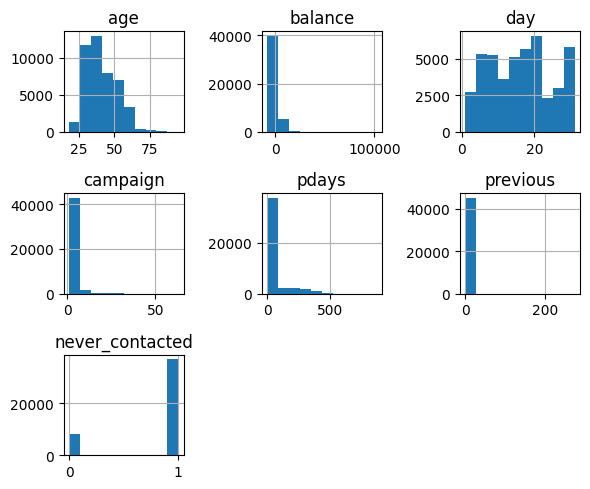

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y,never_contacted
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,0,0,unknown,no,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,0,0,unknown,no,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,0,0,unknown,no,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,0,0,unknown,no,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,0,0,unknown,no,1


In [13]:
#Duration = Time of last call, but if duration =0, then y = no, so we can drop duration to avoid data leakage.
df.drop(columns=['duration'], inplace=True)
df.hist(figsize=(6,5))
plt.tight_layout()
plt.show()
df.head()

C:\Users\ville\AppData\Local\Temp\ipykernel_24580\2608485904.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


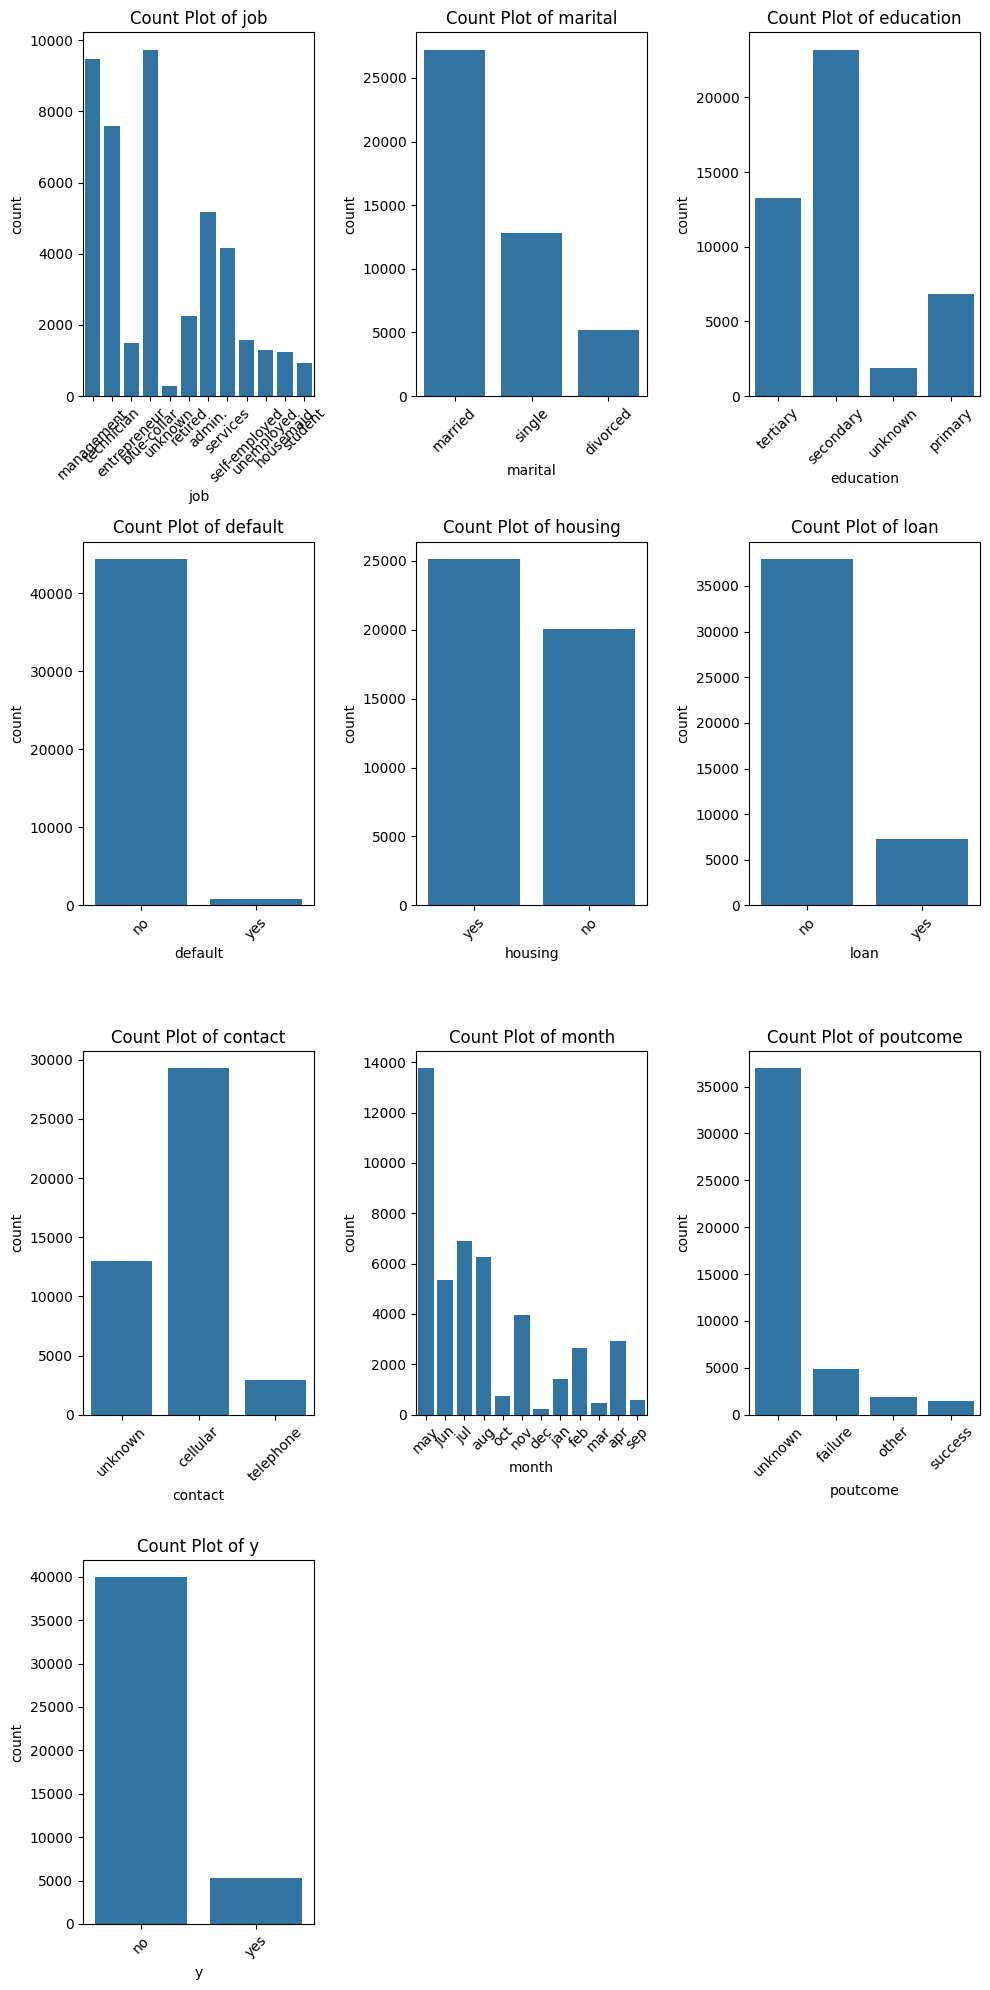

In [14]:

cat_cols = df.select_dtypes(include=['object']).columns

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

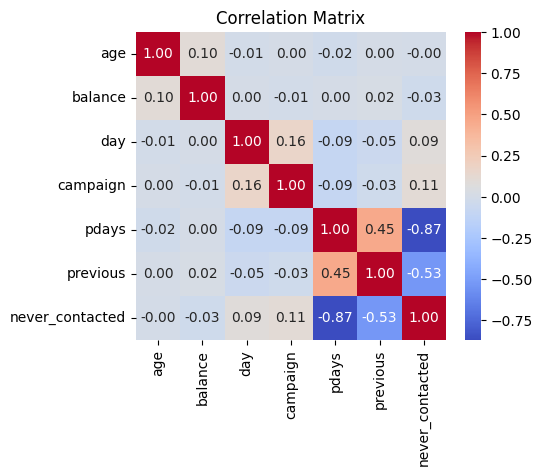

In [16]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Logistic Regression

First, we will perform regular logistic regression without cross-validation as a baseline since performance may be sensitive to the specific train-test split. Later, we will use cross-validation to better evaluate model performance by averaging performance across multiple train-test splits. 

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

X = df.drop("y", axis=1)
X = pd.get_dummies(X, drop_first=True) #Include categorical variables as binary, instead of just numeric variables
y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 3)
#Scale the data to improve model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

For logistic regression, scaling features is important.

In [20]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.89


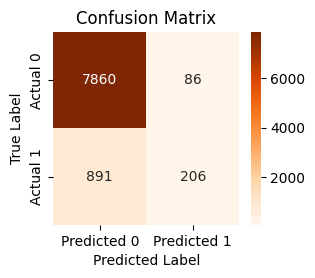

In [22]:
confusion = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(3,2.5))
sns.heatmap(confusion, 
            annot=True, 
            fmt="d", 
            cmap="Oranges",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

From the confusion matrix above, we see a high percentage of correctly predicted results where the customer either subscribed for a term deposit. We see a higher number of false negatives (model predicted the customer did not subscribe but actually did) compared to false positives (model predicted the customer did subscribe by actually didn't).

In [23]:
precision = confusion[1,1] / (confusion[0,1] + confusion[1,1]) if (confusion[0,1] + confusion[1,1]) > 0 else 0
print(f'Precision: {precision:.2f}')
recall = confusion[1,1] / (confusion[1,0] + confusion[1,1]) if (confusion[1,0] + confusion[1,1]) > 0 else 0
print(f'Recall: {recall:.2f}')

Precision: 0.71
Recall: 0.19


Relatively high precision of 0.71 indicates that for those the model predicts will subscribe, 71 percent actually do subscribe. Low recall of 0.19 indicates that only 19 percent of those who actually subscribed were correctly identified (tends to predict not subscribed for actual subscribers unless the model is very confident).

In [24]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]
roc_auc_score(y_test, y_prob)

0.7735998757336726

In [25]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)

                Feature  Coefficient
40     poutcome_success     0.408294
21   education_tertiary     0.113248
34            month_mar     0.108582
11          job_retired     0.092271
37            month_oct     0.087209
39       poutcome_other     0.061803
38            month_sep     0.061662
14          job_student     0.048065
33            month_jun     0.043775
41     poutcome_unknown     0.043466
20  education_secondary     0.041586
1               balance     0.041287
19       marital_single     0.035429
2                   day     0.032931
29            month_dec     0.028910
6       never_contacted     0.024928
22    education_unknown     0.023827
5              previous     0.021762
16       job_unemployed     0.020575
4                 pdays     0.002687
0                   age    -0.002714
23          default_yes    -0.004728
17          job_unknown    -0.005707
10       job_management    -0.011893
15       job_technician    -0.013986
13         job_services    -0.020326
1